In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:\\Users\\DELL\\Documents\\Python\\CSV\\OnlineRetail.csv', encoding = 'latin1', parse_dates = ['InvoiceDate'])

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.drop_duplicates(inplace = True)

In [6]:
df.dropna(inplace = True)

In [7]:
for i in df.columns:
    if df[i].dtypes=='object':
        pass
    else:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

In [8]:
df_new = df.drop(['InvoiceDate'], axis = 1)

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [10]:
for i in df_new.columns:
    if df_new[i].dtypes == 'object':
        df_new[i] = le.fit_transform(df[i])

In [11]:
df_new

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
0,0,3039,3432,6,2.55,17850.0,35
1,0,2478,3440,6,3.39,17850.0,35
2,0,2677,784,8,2.75,17850.0,35
3,0,2629,1673,6,3.39,17850.0,35
4,0,2628,2568,6,3.39,17850.0,35
...,...,...,...,...,...,...,...
541904,16834,1408,2084,12,0.85,12680.0,13
541905,16834,1642,630,6,2.10,12680.0,13
541906,16834,1958,636,4,4.15,12680.0,13
541907,16834,1959,635,4,4.15,12680.0,13


In [12]:
from sklearn.cluster import KMeans

In [13]:
clusters = list(range(2, 8))
ssd = []

for num_clusters in clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=150, random_state=50)
    kmeans.fit(df_new)
    ssd.append(kmeans.inertia_)

In [14]:
ssd

[3619239307710.3184,
 2500719590590.1553,
 2096892639215.136,
 1875518167843.845,
 1670811107986.5461,
 1482876437585.9817]

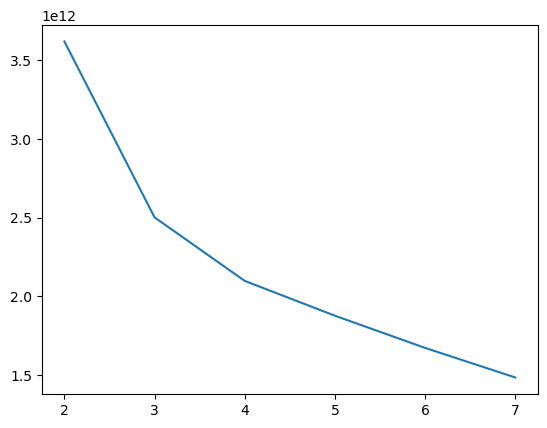

In [15]:
plt.plot(clusters,ssd)

In [16]:
kmodel = KMeans(n_clusters=4, max_iter=150, random_state=50)

In [17]:
kmodel.fit(df_new)

KMeans(max_iter=150, n_clusters=4, random_state=50)

In [18]:
kmodel.cluster_centers_

array([[1.12684546e+04, 1.52277825e+03, 1.88818220e+03, 7.94543459e+00,
        2.20949519e+00, 1.52576723e+04, 3.27599978e+01],
       [2.34610779e+03, 1.36759430e+03, 1.81583791e+03, 7.44189447e+00,
        2.25200616e+00, 1.53290229e+04, 3.30542609e+01],
       [1.52521570e+04, 1.54189894e+03, 1.90422800e+03, 6.07859641e+00,
        2.17981243e+00, 1.53393707e+04, 3.33066099e+01],
       [6.87290435e+03, 1.43567275e+03, 1.89164655e+03, 7.95469335e+00,
        2.16953423e+00, 1.53295606e+04, 3.29905220e+01]])

In [19]:
from sklearn.metrics import silhouette_score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Get the within-cluster sum of squares (WCSS)
wcss = kmodel.inertia_

# Get the silhouette score
labels = kmodel.labels_
silhouette_avg = silhouette_score(df_new, labels)

print("WCSS:", wcss)
print("Silhouette Score:", silhouette_avg)


In [ ]:
silhouette_score(df_new, kmodel.labels_)